In [7]:
from pandas import read_csv

data = read_csv("/Users/yunteee/Documents/GitHub/market-impact-renewables/data/market_impact_renewables.csv")

In [18]:
data.head()

,Date,Demand (ITSDO),Forecasted DA Price,Day Ahead APX Price,Day-Ahead Nordpool Price,Within Day Price (MIDP),DA Forecast Error (EPEX),DA Forecast Error (Nordpool),SETT_DATE,SETT_TIME,...,MAX_FORECAST,MIN_FORECAST,Hour,Year,Month,Day,estimated_load,forecasted_wind_penetration,forecasted_solar_penetration,Daylight Hours
0,2018-04-17 00:00:00,23334.0,28.08,42.00,42.00,34.79,-13.92,13.92,2018-04-17,00:00:00,...,1021.7620,847.413,0,2018,4,1,23011.696559,33.617686,4.054616,13.979722
1,2018-04-17 00:30:00,23490.0,28.08,42.00,42.00,32.29,-13.92,13.92,2018-04-17,00:30:00,...,1019.7570,850.281,0,2018,4,1,24412.411350,31.807591,3.823217,13.979722
2,2018-04-17 01:00:00,23751.0,39.04,40.00,40.00,26.28,-0.96,0.96,2018-04-17,01:00:00,...,1017.7520,853.149,1,2018,4,1,23830.117146,32.949901,3.917912,13.979722
3,2018-04-17 01:30:00,24142.0,39.04,40.00,40.00,24.95,-0.96,0.96,2018-04-17,01:30:00,...,1016.0825,853.898,1,2018,4,1,24177.549868,33.072003,3.859012,13.979722
4,2018-04-17 02:00:00,23886.0,37.84,38.51,38.51,23.57,-0.67,0.67,2018-04-17,02:00:00,...,1014.4130,854.647,2,2018,4,1,24021.649494,33.744560,3.881440,13.979722


In [19]:
df = data[["Year","Day Ahead APX Price","forecasted_solar_penetration","forecasted_wind_penetration"]].rename(
    columns={"Day Ahead APX Price": "price"}
)

In [96]:
df.head()

,Year,price,forecasted_solar_penetration,forecasted_wind_penetration,combined_penetration,penetration_bin
0,2018,42.00,4.054616,33.617686,37.672303,4%-5%
1,2018,42.00,3.823217,31.807591,35.630808,3%-4%
2,2018,40.00,3.917912,32.949901,36.867813,3%-4%
3,2018,40.00,3.859012,33.072003,36.931015,3%-4%
4,2018,38.51,3.881440,33.744560,37.626001,3%-4%


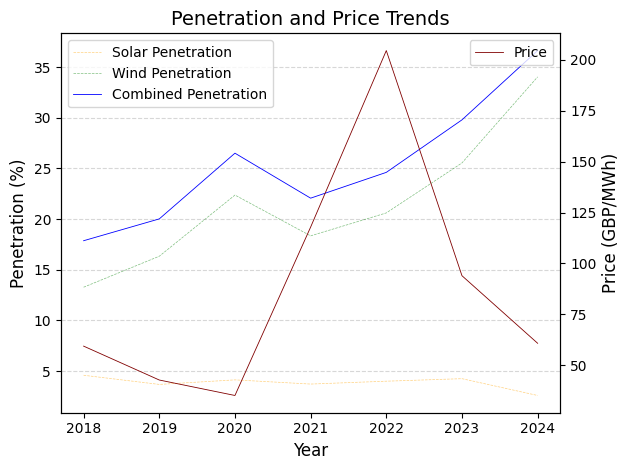

In [97]:
# Calculate combined penetration
df["combined_penetration"] = df["forecasted_solar_penetration"] + df["forecasted_wind_penetration"]

# Average penetration per year vs price
fig, ax1 = plt.subplots()

# Plot solar and wind penetration on the left y-axis
ax1.plot(df.groupby("Year")["forecasted_solar_penetration"].mean(), label="Solar Penetration", color="orange", linewidth = 0.5 ,alpha=0.5, linestyle="--")
ax1.plot(df.groupby("Year")["forecasted_wind_penetration"].mean(), label="Wind Penetration", color="green", linewidth = 0.5, alpha =0.5, linestyle="--")
ax1.plot(df.groupby("Year")["combined_penetration"].mean(), label="Combined Penetration", color="blue", linewidth = 0.6)
ax1.set_ylabel("Penetration (%)", fontsize=12)
ax1.legend(loc="upper left")
ax1.grid(axis="y", linestyle="--", alpha=0.5)

# Create a secondary y-axis for price on the right
ax2 = ax1.twinx()
ax2.plot(df.groupby("Year")["price"].mean(), label="Price", linewidth = 0.6, color="maroon")
ax2.set_ylabel("Price (GBP/MWh)", fontsize=12)
ax2.legend(loc="upper right")

# Add labels and title
ax1.set_xlabel("Year", fontsize=12)
plt.title("Penetration and Price Trends", fontsize=14)

plt.tight_layout()
plt.show()


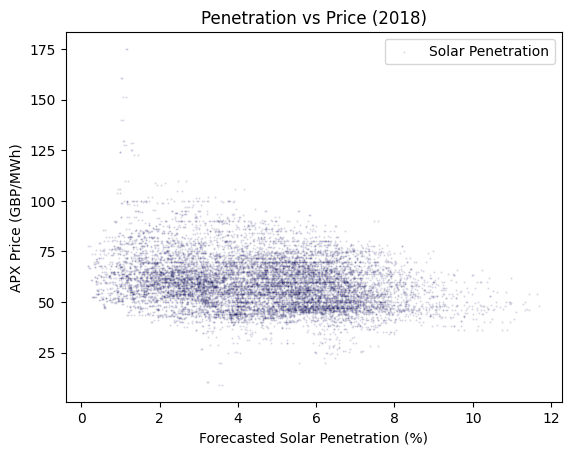

In [98]:
# Penetration vs Price (2018)

df_2018 = df[df["Year"] == 2018]

plt.scatter(df_2018["forecasted_solar_penetration"], df_2018["price"], label="Solar Penetration",
            facecolor='blue', edgecolor='black', alpha=0.1,
            s=1, linewidths=0.5)

# Add labels and legend
plt.xlabel("Forecasted Solar Penetration (%)")
plt.ylabel("APX Price (GBP/MWh)")
plt.legend()
plt.title("Penetration vs Price (2018)")
plt.show()


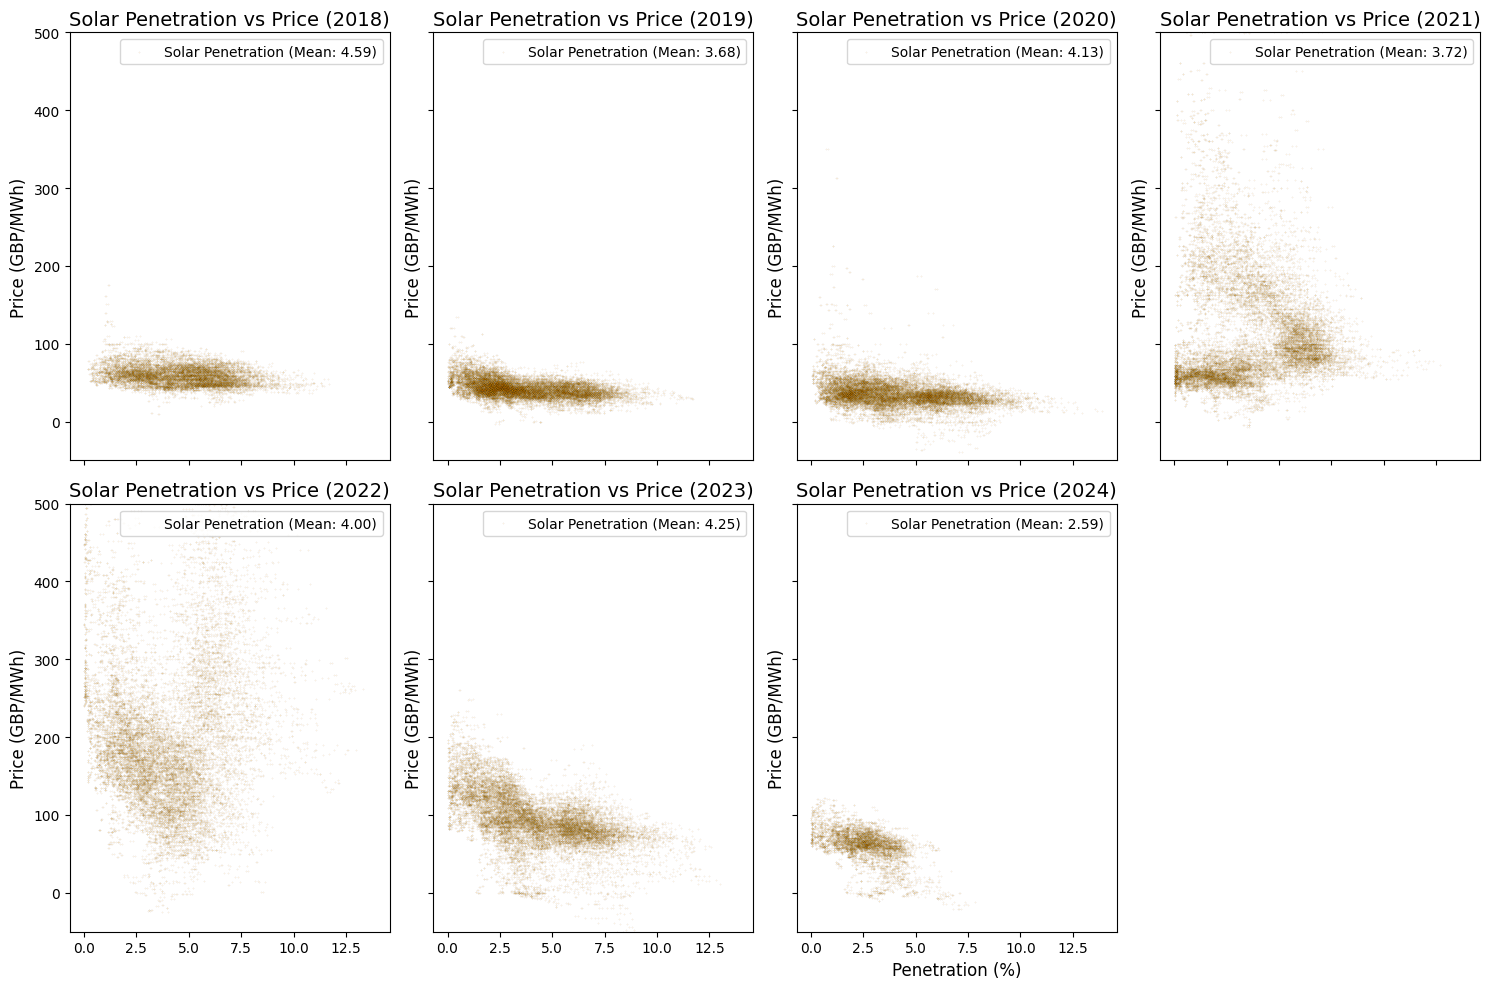

In [99]:
# Define the years you want to plot
years = range(2018, 2025)

# Create subplots with 2 rows and 3 columns
fig, axes = plt.subplots(2, 4, figsize=(15, 10), sharex=True, sharey=True)

# Flatten the axes array for easier indexing
axes = axes.flatten()

# Loop through each year and plot the scatter plots
for i, year in enumerate(years):
    df_year = df[df["Year"] == year]  # Filter for the specific year
    ax = axes[i]  # Get the corresponding subplot axis

    # Calculate the mean solar penetration for the year
    mean_solar_penetration = df_year["forecasted_solar_penetration"].mean()

    # Plot solar and wind penetration vs price
    ax.scatter(df_year["forecasted_solar_penetration"], df_year["price"],
               label=f"Solar Penetration (Mean: {mean_solar_penetration:.2f})",
               facecolor='orange', edgecolor='black', alpha=0.1,
                s=1, linewidths=0.2)

    # Add labels, title, and legend
    ax.set_title(f"Solar Penetration vs Price ({year})", fontsize=14)
    ax.set_ylabel("Price (GBP/MWh)", fontsize=12)
    ax.legend(loc="upper right")

    # Set y-axis limits
    ax.set_ylim(-50, 500)

# Remove the last unused subplot (8th box)
fig.delaxes(axes[-1])

# Add a common x-axis label
plt.xlabel("Penetration (%)", fontsize=12)

# Adjust layout to prevent overlap
plt.tight_layout()
#plt.show()

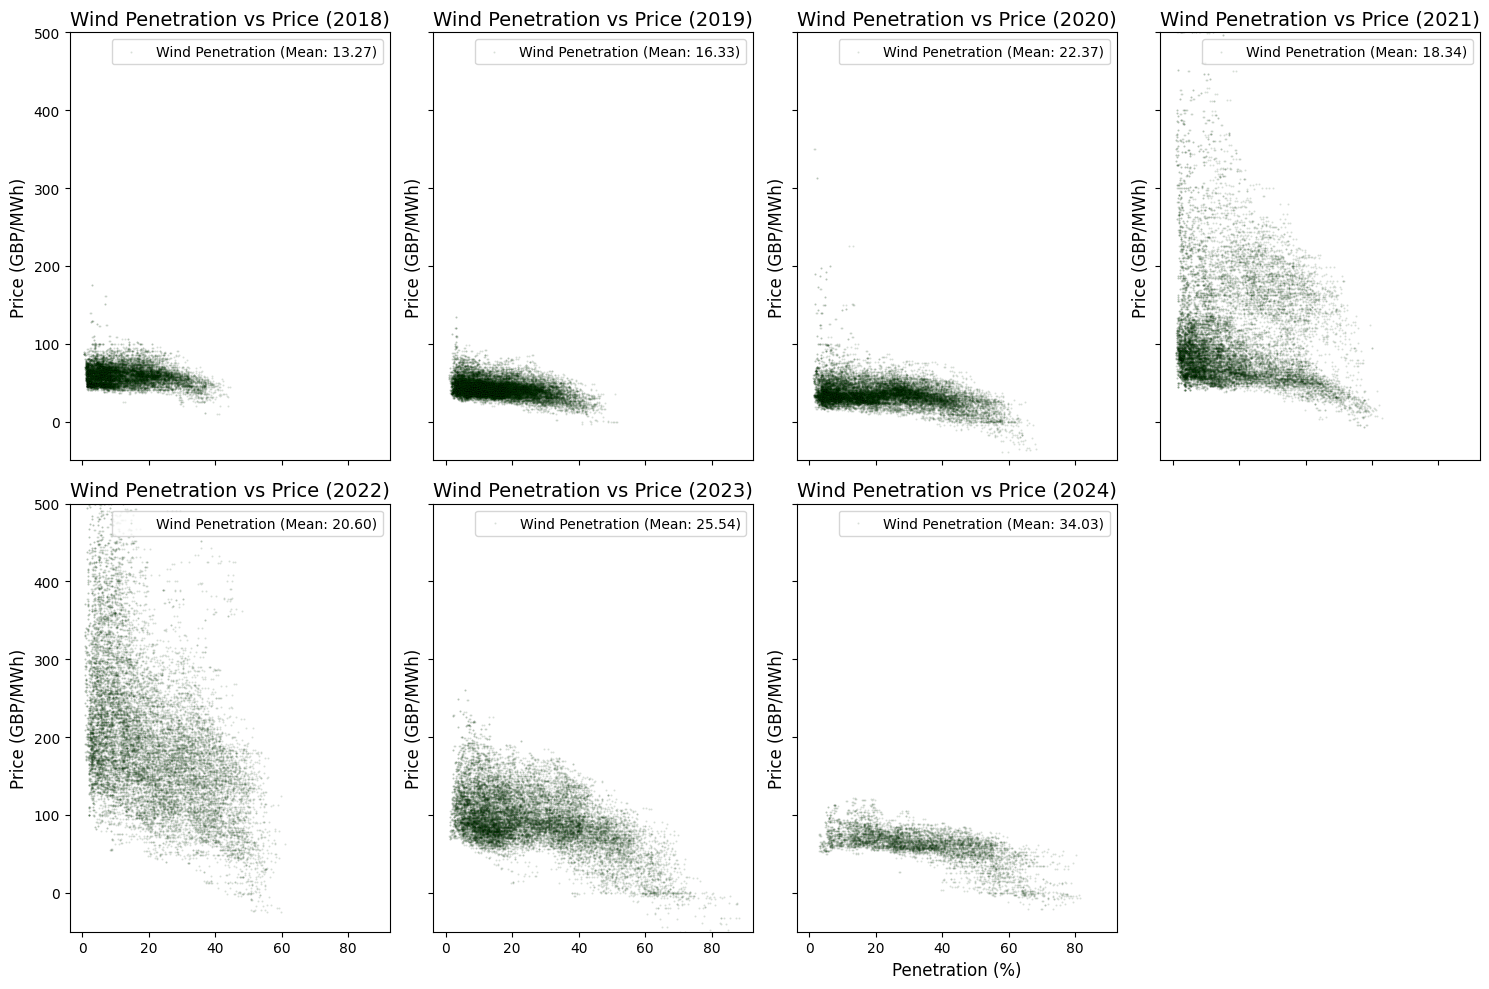

In [100]:
# Same for wind penetration vs price

# Define the years you want to plot
years = range(2018, 2025)

# Create subplots with 2 rows and 3 columns
fig, axes = plt.subplots(2, 4, figsize=(15, 10), sharex=True, sharey=True)

# Flatten the axes array for easier indexing
axes = axes.flatten()

# Loop through each year and plot the scatter plots
for i, year in enumerate(years):
    df_year = df[df["Year"] == year]  # Filter for the specific year
    ax = axes[i]  # Get the corresponding subplot axis

    # Calculate the mean solar penetration for the year
    mean_wind_penetration = df_year["forecasted_wind_penetration"].mean()

    # Plot solar and wind penetration vs price
    ax.scatter(df_year["forecasted_wind_penetration"], df_year["price"],
               label=f"Wind Penetration (Mean: {mean_wind_penetration:.2f})",
               facecolor='green', edgecolor='black', alpha=0.1,
                s=1, linewidths=0.5)

    # Add labels, title, and legend
    ax.set_title(f"Wind Penetration vs Price ({year})", fontsize=14)
    ax.set_ylabel("Price (GBP/MWh)", fontsize=12)
    ax.legend(loc="upper right")

    # Set y-axis limits
    ax.set_ylim(-50, 500)

# Remove the last unused subplot (8th box)
fig.delaxes(axes[-1])

# Add a common x-axis label
plt.xlabel("Penetration (%)", fontsize=12)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

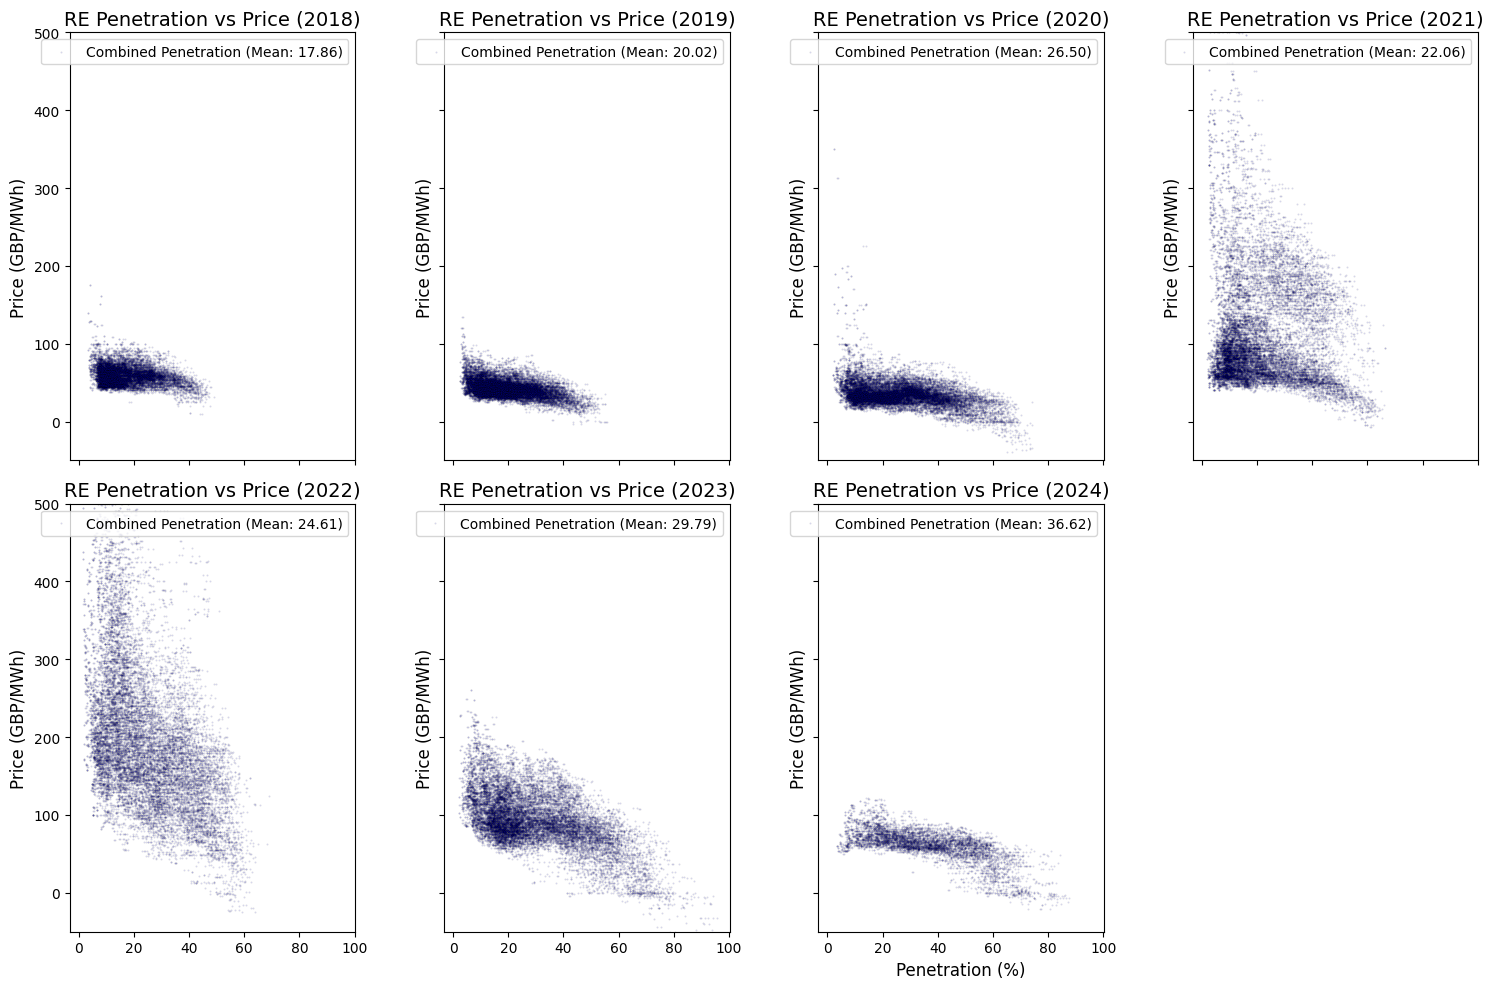

In [101]:
# Combined Penetration vs Price

# Calculate combined penetration
df["combined_penetration"] = df["forecasted_solar_penetration"] + df["forecasted_wind_penetration"]

# Define the years you want to plot
years = range(2018, 2025)

# Create subplots with 2 rows and 4 columns
fig, axes = plt.subplots(2, 4, figsize=(15, 10), sharex=True, sharey=True)

# Flatten the axes array for easier indexing
axes = axes.flatten()

# Loop through each year and plot the scatter plots
for i, year in enumerate(years):
    df_year = df[df["Year"] == year]  # Filter for the specific year
    ax = axes[i]  # Get the corresponding subplot axis

    # Calculate the mean solar penetration for the year
    mean_RE_penetration = df_year["combined_penetration"].mean()

    # Plot solar and wind penetration vs price
    ax.scatter(df_year["combined_penetration"], df_year["price"],
               label=f"Combined Penetration (Mean: {mean_RE_penetration:.2f})",
               facecolor='blue', edgecolor='black', alpha=0.1,
                s=1, linewidths=0.5)

    # Add labels, title, and legend
    ax.set_title(f"RE Penetration vs Price ({year})", fontsize=14)
    ax.set_ylabel("Price (GBP/MWh)", fontsize=12)
    ax.legend(loc="upper right")

    # Set y-axis limits
    ax.set_ylim(-50, 500)

# Remove the last unused subplot (6th box)
fig.delaxes(axes[-1])

# Add a common x-axis label
plt.xlabel("Penetration (%)", fontsize=12)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

In [87]:
df.head()

,Year,price,forecasted_solar_penetration,forecasted_wind_penetration,combined_penetration,penetration_bin
0,2018,42.00,4.054616,33.617686,37.672303,31%-40%
1,2018,42.00,3.823217,31.807591,35.630808,31%-40%
2,2018,40.00,3.917912,32.949901,36.867813,31%-40%
3,2018,40.00,3.859012,33.072003,36.931015,31%-40%
4,2018,38.51,3.881440,33.744560,37.626001,31%-40%


/var/folders/tk/4l42lj7x1tvgq9_g3x1y15g40000gn/T/ipykernel_9729/1767473746.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby("penetration_bin")["price"]


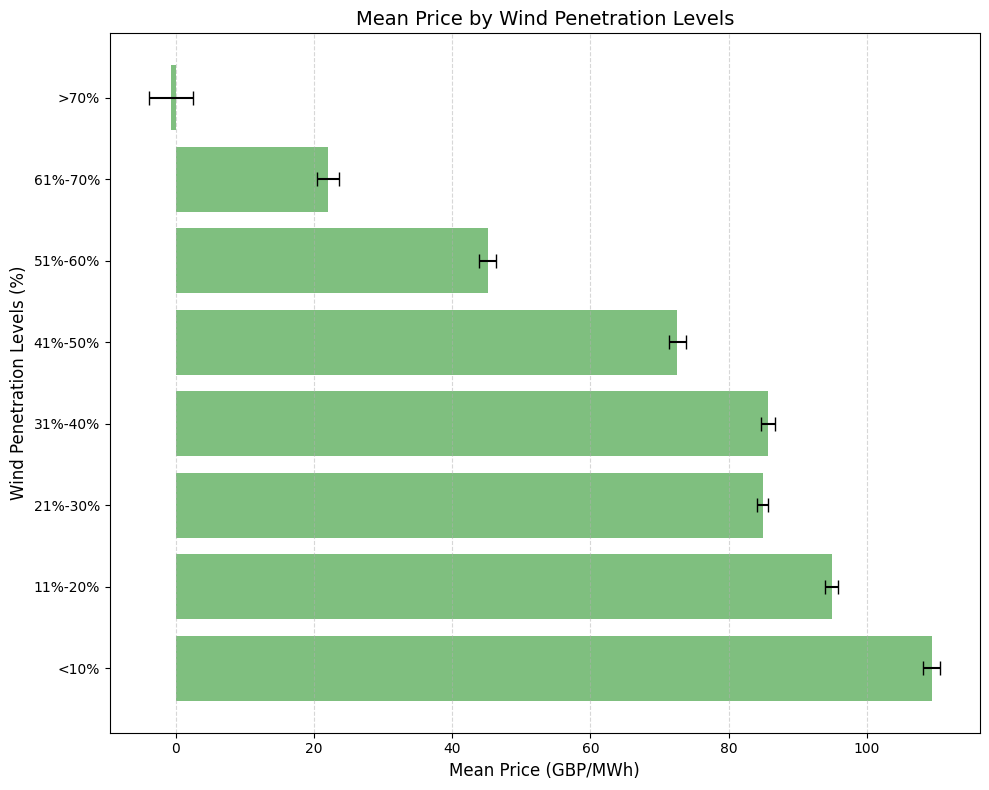

In [102]:
# Replication - BAR PLOT: WIND
import pandas as pd
import numpy as np
import scipy.stats as stats

# Define the penetration bins and labels
bins = [0, 10, 20, 30, 40, 50, 60, 70, 101]  # Combine >70% into one bin
bin_labels = ["<10%", "11%-20%", "21%-30%", "31%-40%", "41%-50%", "51%-60%", "61%-70%", ">70%"]

# Add a new column to the DataFrame for binned penetration levels
df["penetration_bin"] = pd.cut(
    df["forecasted_wind_penetration"], 
    bins=bins, 
    labels=bin_labels, 
    right=False
)

# Group by penetration bins and calculate mean price and confidence intervals
grouped = df.groupby("penetration_bin")["price"]
mean_prices = grouped.mean()
conf_intervals = grouped.apply(lambda x: stats.sem(x) * stats.t.ppf((1 + 0.95) / 2, len(x) - 1))

# Create the horizontal bar plot
plt.figure(figsize=(10, 8))
plt.barh(bin_labels, mean_prices, xerr=conf_intervals, capsize=5, color="green", alpha=0.5)

# Add labels, title, and grid
plt.ylabel("Wind Penetration Levels (%)", fontsize=12)
plt.xlabel("Mean Price (GBP/MWh)", fontsize=12)
plt.title("Mean Price by Wind Penetration Levels", fontsize=14)
plt.grid(axis="x", linestyle="--", alpha=0.5)

# Show the plot
plt.tight_layout()
plt.show()

/var/folders/tk/4l42lj7x1tvgq9_g3x1y15g40000gn/T/ipykernel_9729/4150006984.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby("penetration_bin")["price"]


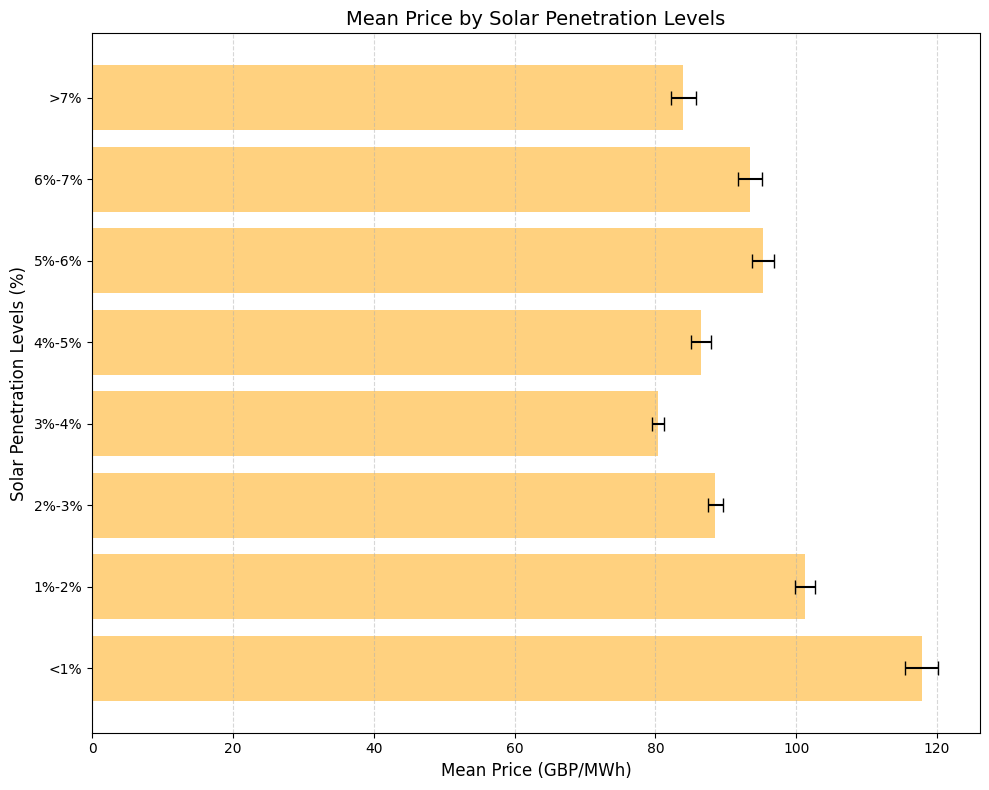

In [103]:
# BAR PLOT - SOLAR

# Define the penetration bins and labels
bins = [0, 1, 2, 3, 4, 5, 6, 7, 101]  # Combine >70% into one bin
bin_labels = ["<1%", "1%-2%", "2%-3%", "3%-4%", "4%-5%", "5%-6%", "6%-7%", ">7%"]

# Add a new column to the DataFrame for binned penetration levels
df["penetration_bin"] = pd.cut(
    df["forecasted_solar_penetration"], 
    bins=bins, 
    labels=bin_labels, 
    right=False
)

# Group by penetration bins and calculate mean price and confidence intervals
grouped = df.groupby("penetration_bin")["price"]
mean_prices = grouped.mean()
conf_intervals = grouped.apply(lambda x: stats.sem(x) * stats.t.ppf((1 + 0.95) / 2, len(x) - 1))

# Create the horizontal bar plot
plt.figure(figsize=(10, 8))
plt.barh(bin_labels, mean_prices, xerr=conf_intervals, capsize=5, color="orange", alpha=0.5)

# Add labels, title, and grid
plt.ylabel("Solar Penetration Levels (%)", fontsize=12)
plt.xlabel("Mean Price (GBP/MWh)", fontsize=12)
plt.title("Mean Price by Solar Penetration Levels", fontsize=14)
plt.grid(axis="x", linestyle="--", alpha=0.5)

# Show the plot
plt.tight_layout()
plt.show()